# Mailbox HOG + Color Random Forest Training Pipeline

This trains the model used by **Mailbox Classifier v0.2.0**.

Compared with the first baseline, this version adds **Histogram of Oriented Gradients (HOG)**.
HOG captures local edge and shape structure, while the existing color features capture
brightness and color distribution.

Expected dataset:

```text
dataset/
├── empty/
└── occupied/
```


In [5]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict


In [6]:
DATASET_DIR = Path("/Volumes/frigate/mailbox_dataset")
MODEL_OUT = Path("mailbox_rf.joblib")
METADATA_OUT = Path("mailbox_rf_metadata.json")

RANDOM_STATE = 42
N_ESTIMATORS = 400

HOG_SIZE = (160, 120)  # width, height
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)


In [13]:
def extract_features(image_path: str) -> np.ndarray:
    with Image.open(image_path) as im:
        rgb = im.convert("RGB").resize((320, 240))
        arr = np.asarray(rgb, dtype=np.uint8)
        feats = []

        # RGB histograms
        for c in range(3):
            hist, _ = np.histogram(arr[:, :, c], bins=32, range=(0, 256), density=True)
            feats.extend(hist.tolist())

        # HSV histograms
        hsv = np.asarray(rgb.convert("HSV"), dtype=np.uint8)
        for c in range(3):
            hist, _ = np.histogram(hsv[:, :, c], bins=32, range=(0, 256), density=True)
            feats.extend(hist.tolist())

        # Grayscale histogram
        gray = np.asarray(rgb.convert("L"), dtype=np.uint8)
        hist, _ = np.histogram(gray, bins=32, range=(0, 256), density=True)
        feats.extend(hist.tolist())

        # Global statistics
        feats.extend(arr.mean(axis=(0, 1)).tolist())
        feats.extend(arr.std(axis=(0, 1)).tolist())
        feats.append(float(gray.mean()))
        feats.append(float(gray.std()))

        # Simple edge density
        dx = np.abs(np.diff(gray.astype(np.int16), axis=1))
        dy = np.abs(np.diff(gray.astype(np.int16), axis=0))
        edge_density = float((dx > 20).mean() + (dy > 20).mean()) / 2.0
        feats.append(edge_density)

        # HOG
        hog_gray = np.asarray(
            rgb.convert("L").resize(HOG_SIZE),
            dtype=np.float32
        ) / 255.0

        hog_features = hog(
            hog_gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm="L2-Hys",
            feature_vector=True,
        )

        feats.extend(hog_features.tolist())

    return np.asarray(feats, dtype=np.float32)


In [14]:
extensions = {".jpg", ".jpeg", ".png", ".webp"}

rows = []
for label in ["empty", "occupied"]:
    folder = DATASET_DIR / label
    if not folder.exists():
        raise FileNotFoundError(f"Missing folder: {folder}")

    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() in extensions:
            rows.append({"path": path, "label": label})

df = pd.DataFrame(rows)

print(df["label"].value_counts())
print(f"Total images: {len(df)}")
df.head()


label
empty       44
occupied    43
Name: count, dtype: int64
Total images: 87


,path,label
0,/Volumes/frigate/mailbox_dataset/empty/mailbox...,empty
1,/Volumes/frigate/mailbox_dataset/empty/mailbox...,empty
2,/Volumes/frigate/mailbox_dataset/empty/mailbox...,empty
3,/Volumes/frigate/mailbox_dataset/empty/mailbox...,empty
4,/Volumes/frigate/mailbox_dataset/empty/mailbox...,empty


In [15]:
X = np.vstack([extract_features(str(p)) for p in df["path"]])
y = df["label"].to_numpy()

print("Feature matrix:", X.shape)
print("Feature count per image:", X.shape[1])


Feature matrix: (87, 9809)
Feature count per image: 9809


## Cross-validation

The critical failure for this project is **false empty**:
a package or letter is present, but the classifier says the mailbox is empty.

For a small dataset we use stratified cross-validation rather than trusting one train/test split.


              precision    recall  f1-score   support

       empty      0.957     1.000     0.978        44
    occupied      1.000     0.953     0.976        43

    accuracy                          0.977        87
   macro avg      0.978     0.977     0.977        87
weighted avg      0.978     0.977     0.977        87



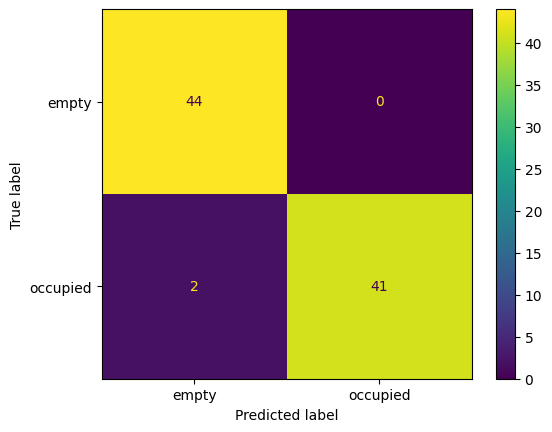

False empty: 2
False occupied: 0


In [16]:
class_counts = df["label"].value_counts()
min_class = int(class_counts.min())

if min_class >= 3:
    n_splits = min(5, min_class)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    cv_model = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=1,
        max_features="sqrt",
    )

    y_pred = cross_val_predict(cv_model, X, y, cv=cv, method="predict")

    print(classification_report(y, y_pred, digits=3))

    cm = confusion_matrix(y, y_pred, labels=["empty", "occupied"])
    ConfusionMatrixDisplay(cm, display_labels=["empty", "occupied"]).plot()
    plt.show()

    false_empty = int(((y == "occupied") & (y_pred == "empty")).sum())
    false_occupied = int(((y == "empty") & (y_pred == "occupied")).sum())

    print("False empty:", false_empty)
    print("False occupied:", false_occupied)
else:
    print("Not enough examples per class for reliable cross-validation.")
    print("Collect at least 3 per class; 20–30+ per class is much better.")


## Train final HOG + color Random Forest


In [17]:
model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
    min_samples_leaf=1,
    max_features="sqrt",
)

model.fit(X, y)
joblib.dump(model, MODEL_OUT)

metadata = {
    "classifier": "hog_color_random_forest",
    "classes": [str(c) for c in model.classes_],
    "feature_count": int(X.shape[1]),
    "training_images": int(len(df)),
    "class_counts": {k: int(v) for k, v in df["label"].value_counts().to_dict().items()},
    "n_estimators": N_ESTIMATORS,
    "random_state": RANDOM_STATE,
    "hog_size": HOG_SIZE,
    "hog_orientations": HOG_ORIENTATIONS,
    "hog_pixels_per_cell": HOG_PIXELS_PER_CELL,
    "hog_cells_per_block": HOG_CELLS_PER_BLOCK,
}

METADATA_OUT.write_text(json.dumps(metadata, indent=2))
print(f"Saved model: {MODEL_OUT.resolve()}")
print(f"Saved metadata: {METADATA_OUT.resolve()}")


Saved model: /Users/pbs/pythonProjects/mailbox-classifier-hog/training/mailbox_rf.joblib
Saved metadata: /Users/pbs/pythonProjects/mailbox-classifier-hog/training/mailbox_rf_metadata.json


## Feature importance


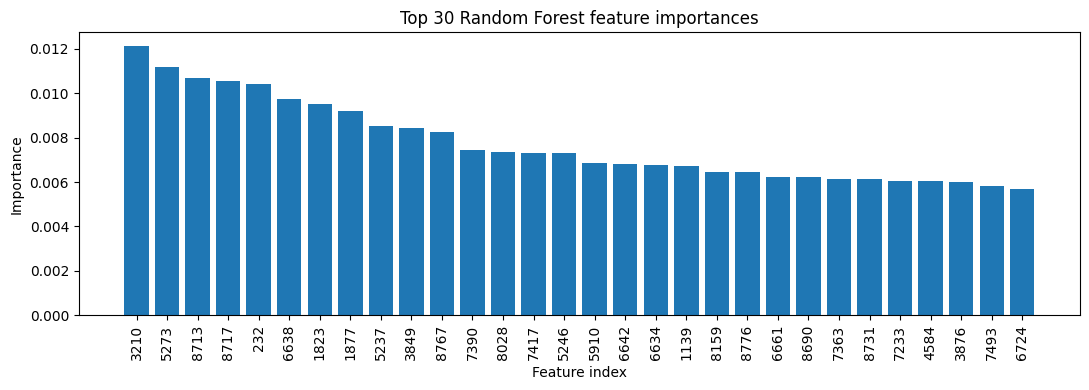

In [18]:
importances = model.feature_importances_
top_idx = np.argsort(importances)[::-1][:30]

plt.figure(figsize=(11, 4))
plt.bar(range(len(top_idx)), importances[top_idx])
plt.xticks(range(len(top_idx)), top_idx, rotation=90)
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.title("Top 30 Random Forest feature importances")
plt.tight_layout()
plt.show()


## Deploy

Copy:

```text
mailbox_rf.joblib
```

to:

```text
/data/mailbox_rf.joblib
```

inside the Home Assistant App, then restart the App or call `POST /reload`.
